In [1]:
# Libraries to help with reading and manipulating data

import pandas as pd
import numpy as np

# for visualizing data
import matplotlib.pyplot as plt
import seaborn as sns

# For randomized data splitting
from sklearn.model_selection import train_test_split

# To build linear regression_model
import statsmodels.api as sm

# To check model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error

#Importing data set

df=pd.read_csv('ottdata.csv')

In [2]:
#Checking the shape of the data

print("There are",df.shape[0],"rows and",df.shape[1],"columns.")

There are 1000 rows and 8 columns.


In [3]:
#Checking the data types of the columns

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   visitors            1000 non-null   float64
 1   ad_impressions      1000 non-null   float64
 2   major_sports_event  1000 non-null   int64  
 3   genre               1000 non-null   object 
 4   dayofweek           1000 non-null   object 
 5   season              1000 non-null   object 
 6   views_trailer       1000 non-null   float64
 7   views_content       1000 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 62.6+ KB


In [4]:
#Check for missing values in the data

df.isnull().sum()

visitors              0
ad_impressions        0
major_sports_event    0
genre                 0
dayofweek             0
season                0
views_trailer         0
views_content         0
dtype: int64

In [5]:
#Check for duplicate rows in the data

df.duplicated().sum()

0

In [6]:
#checking the statistical summary of the data

df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
visitors,1000.0,NaN,NaN,NaN,1.70429,0.231973,1.25,1.55,1.7,1.83,2.34
ad_impressions,1000.0,NaN,NaN,NaN,1434.71229,289.534834,1010.87,1210.33,1383.58,1623.67,2424.2
major_sports_event,1000.0,NaN,NaN,NaN,0.4,0.490143,0.0,0.0,0.0,1.0,1.0
genre,1000,8,Others,255,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dayofweek,1000,7,Friday,369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
season,1000,4,Winter,257,NaN,NaN,NaN,NaN,NaN,NaN,NaN
views_trailer,1000.0,NaN,NaN,NaN,66.91559,35.00108,30.08,50.9475,53.96,57.755,199.92
views_content,1000.0,NaN,NaN,NaN,0.4734,0.105914,0.22,0.4,0.45,0.52,0.89


In [7]:
#Replacing the major_sports_event column from 1/0 to yes/no
df['major_sports_event'] = df['major_sports_event'].replace({1: 'Yes', 0: 'No'})

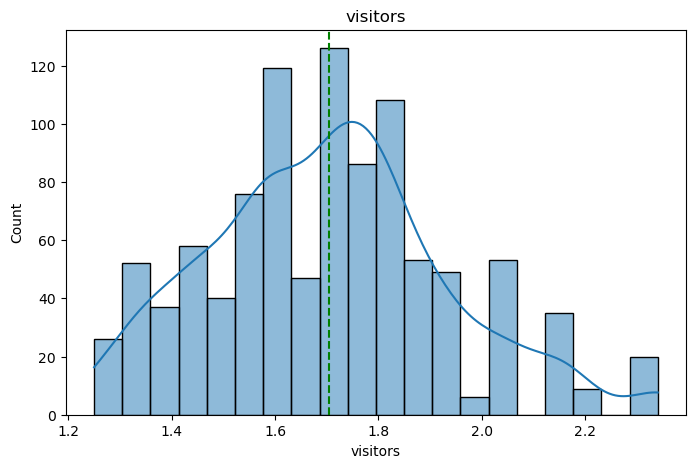

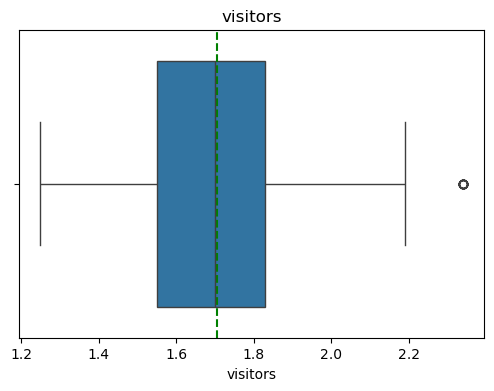

In [8]:
#Univariate Analysis
#Exploring individual variables (both categorical and numerical), highlighting any findings or outliers in the data
#Visitor Uni_Analysis
plt.figure(figsize=(8, 5))
plt.title("visitors")
sns.histplot(data=df, x='visitors', kde=True)
plt.axvline(x=df['visitors'].mean(), color='green', linestyle='--', label='Mean')
plt.grid(False)
plt.show()

plt.figure(figsize=(6, 4))
plt.title("visitors")
sns.boxplot(data=df, x='visitors')
plt.axvline(x=df['visitors'].mean(), color='green', linestyle='--', label='Mean')
plt.grid(False)
plt.show()

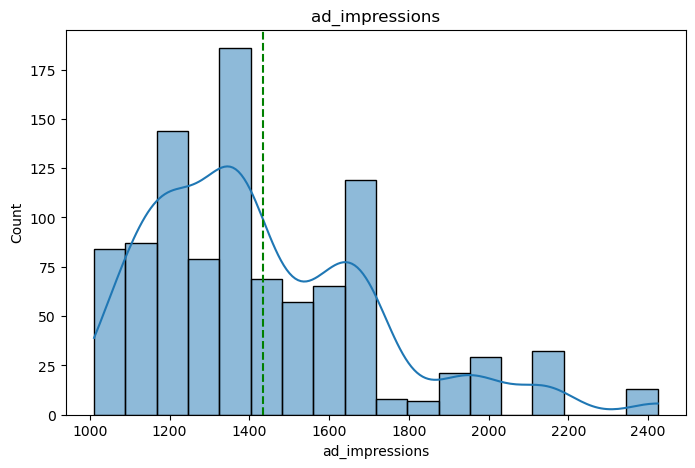

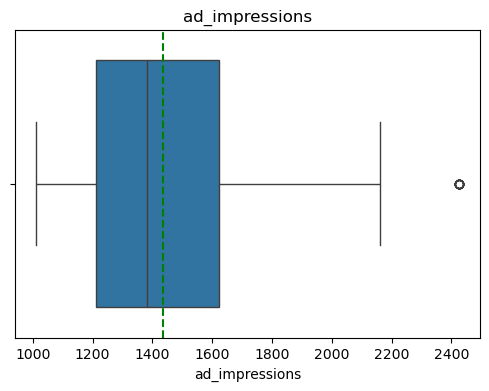

In [9]:
#ad_impressions Uni_Analysis
plt.figure(figsize=(8, 5))
plt.title("ad_impressions")
sns.histplot(data=df, x='ad_impressions', kde=True)
plt.axvline(x=df['ad_impressions'].mean(), color='green', linestyle='--', label='Mean')
plt.grid(False)
plt.show()

plt.figure(figsize=(6, 4))
plt.title("ad_impressions")
sns.boxplot(data=df, x='ad_impressions')
plt.axvline(x=df['ad_impressions'].mean(), color='green', linestyle='--', label='Mean')
plt.grid(False)
plt.show()

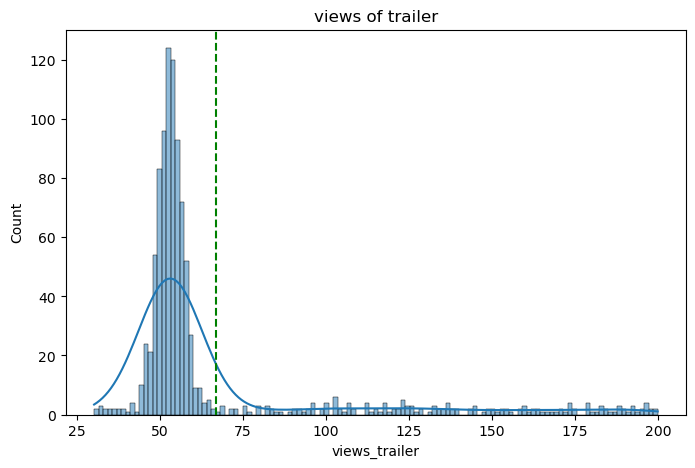

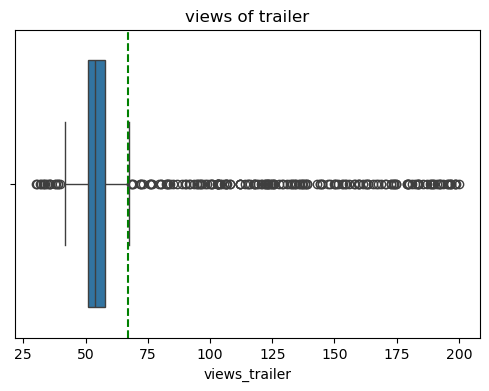

In [10]:
#views of trailer Uni_Analysis
plt.figure(figsize=(8, 5))
plt.title("views of trailer")
sns.histplot(data=df, x='views_trailer', kde=True)
plt.axvline(x=df['views_trailer'].mean(), color='green', linestyle='--', label='Mean')
plt.grid(False)
plt.show()

plt.figure(figsize=(6, 4))
plt.title("views of trailer")
sns.boxplot(data=df, x='views_trailer')
plt.axvline(x=df['views_trailer'].mean(), color='green', linestyle='--', label='Mean')
plt.grid(False)
plt.show()

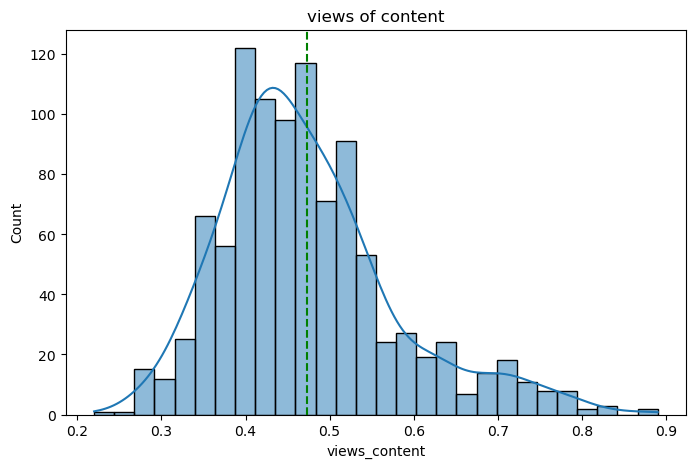

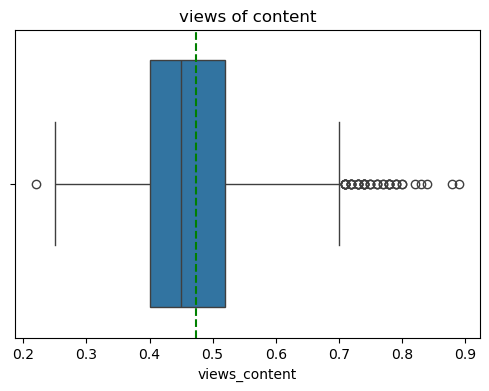

In [11]:
#views_content Uni_Analysis
plt.figure(figsize=(8, 5))
plt.title("views of content")
sns.histplot(data=df, x='views_content', kde=True)
plt.axvline(x=df['views_content'].mean(), color='green', linestyle='--', label='Mean')
plt.grid(False)
plt.show()

plt.figure(figsize=(6, 4))
plt.title("views of content")
sns.boxplot(data=df, x='views_content')
plt.axvline(x=df['views_content'].mean(), color='green', linestyle='--', label='Mean')
plt.grid(False)
plt.show()

C:\Users\Subhadip\AppData\Local\Temp\ipykernel_19308\1377236692.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='genre',palette='Set2')


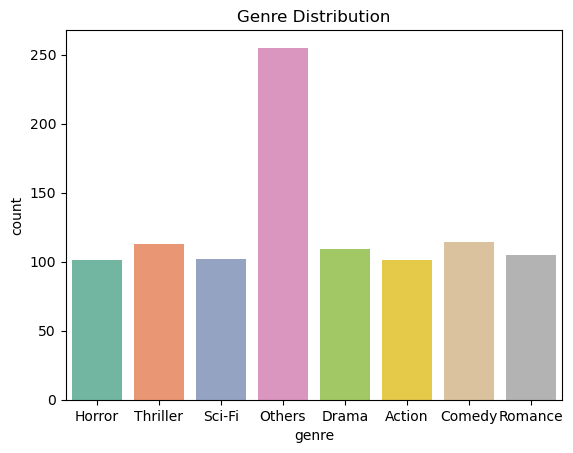

In [12]:
#Genre Uni_Analysis
sns.countplot(data=df,x='genre',palette='Set2')
plt.title("Genre Distribution")
plt.grid(False)
plt.show()

C:\Users\Subhadip\AppData\Local\Temp\ipykernel_19308\3275335087.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='dayofweek', palette='Set2')


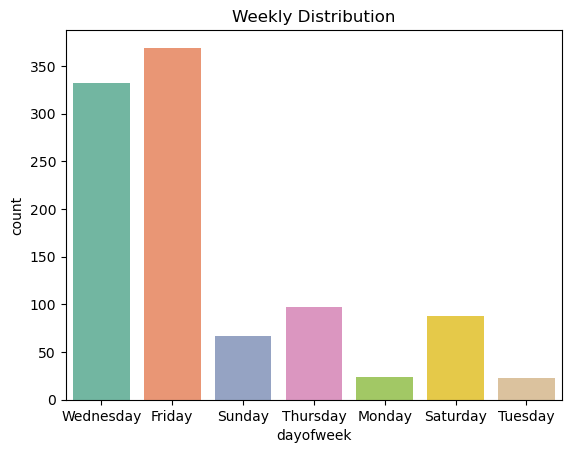

In [13]:
# Weekly Distribution Uni_Analysis
sns.countplot(data=df, x='dayofweek', palette='Set2')
plt.title("Weekly Distribution")
plt.grid(False)
plt.show()

C:\Users\Subhadip\AppData\Local\Temp\ipykernel_19308\535929403.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='season',palette='Set2')


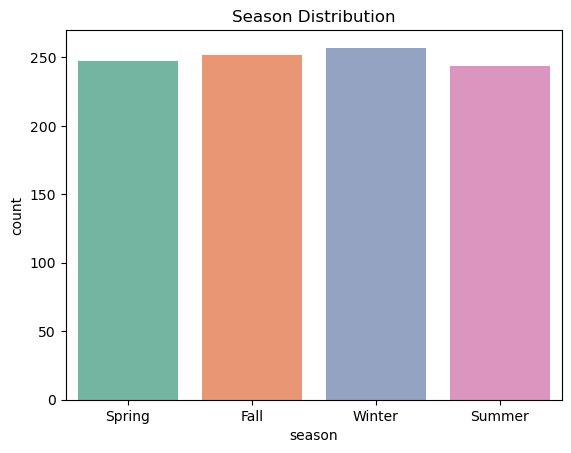

In [14]:
# Season Distribution Uni_Analysis
sns.countplot(data=df,x='season',palette='Set2')
plt.title("Season Distribution")
plt.grid(False)
plt.show()

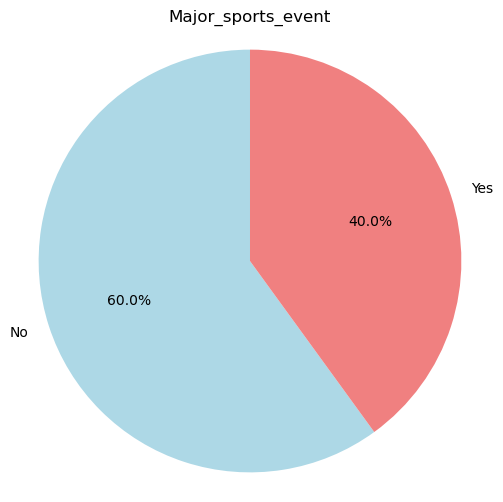

In [15]:
major_sports_event = df['major_sports_event'].value_counts()

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(major_sports_event, 
        labels=major_sports_event.index, 
        autopct='%1.1f%%',      
        startangle=90,          
        colors=['lightblue', 'lightcoral', 'lightgreen'])

plt.title('Major_sports_event')
plt.axis('equal')
plt.show()

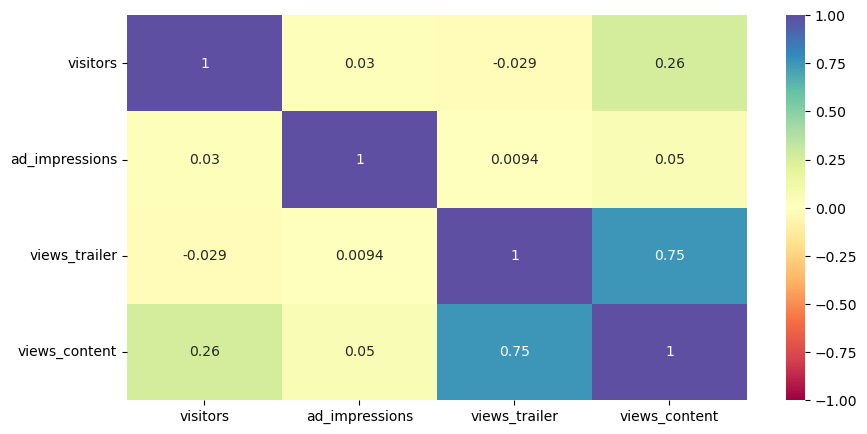

In [16]:
#Bivariate Analysis
##Explore all the numerical variables and check their association with each other

N_df=df.select_dtypes(include='number')

plt.figure(figsize=(10,5))
sns.heatmap(N_df.corr(),
 annot=True, cmap='Spectral', vmin =-1, vmax=1)
plt.show()

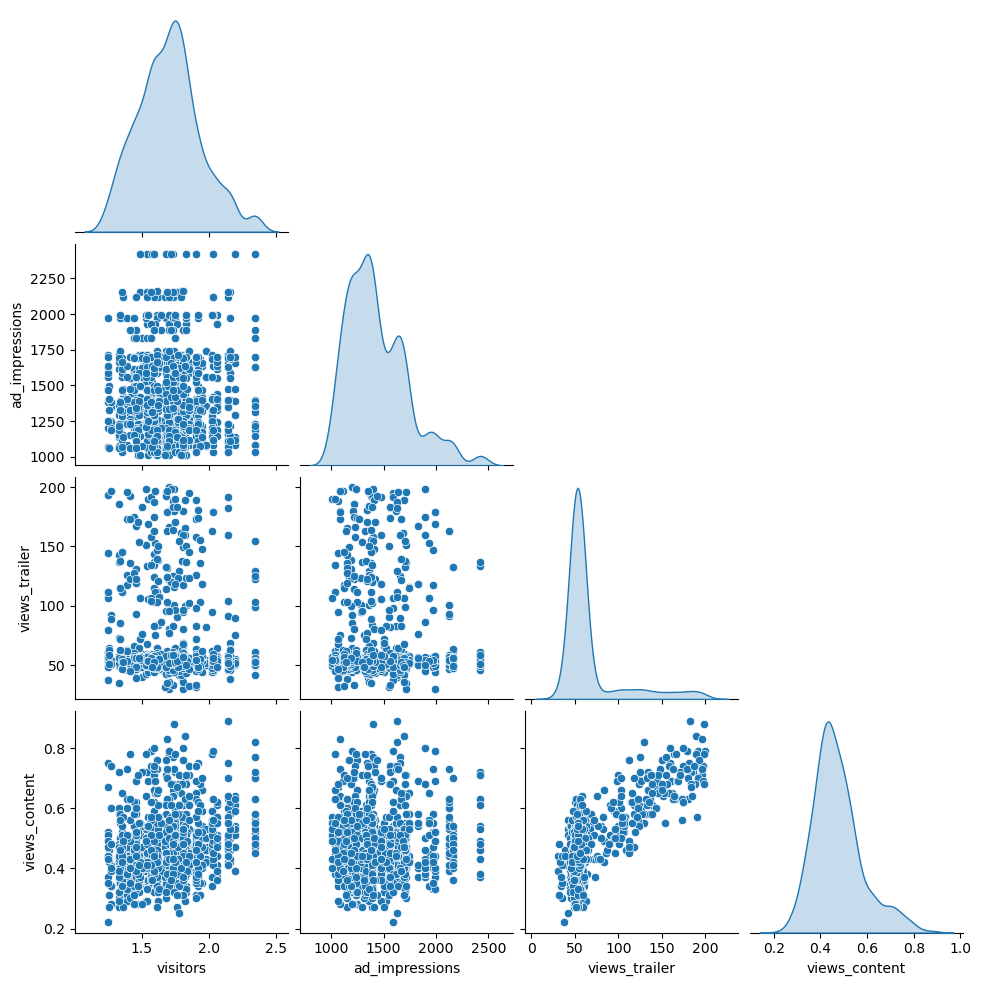

In [17]:
#Pair Plot

g = sns.pairplot(
    data=df,
    vars=['visitors', 'ad_impressions', 'views_trailer', 'views_content'],
    diag_kind="kde",
    corner=True
)

# Turn off gridlines for all subplots
for ax in g.axes.flatten():
    if ax is not None:
        ax.grid(False)

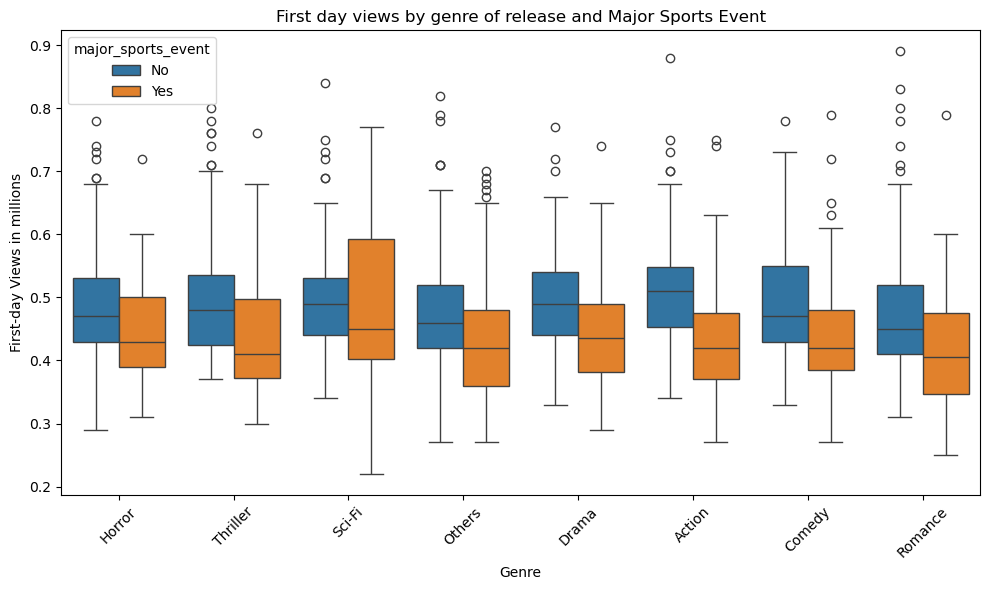

In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='genre',
    y='views_content',
    hue='major_sports_event',
    data=df,
)

plt.title('First day views by genre of release and Major Sports Event')
plt.xlabel('Genre')
plt.ylabel('First-day Views in millions')
plt.legend(title='major_sports_event', loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(False)
plt.show()

C:\Users\Subhadip\AppData\Local\Temp\ipykernel_19308\2252004380.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


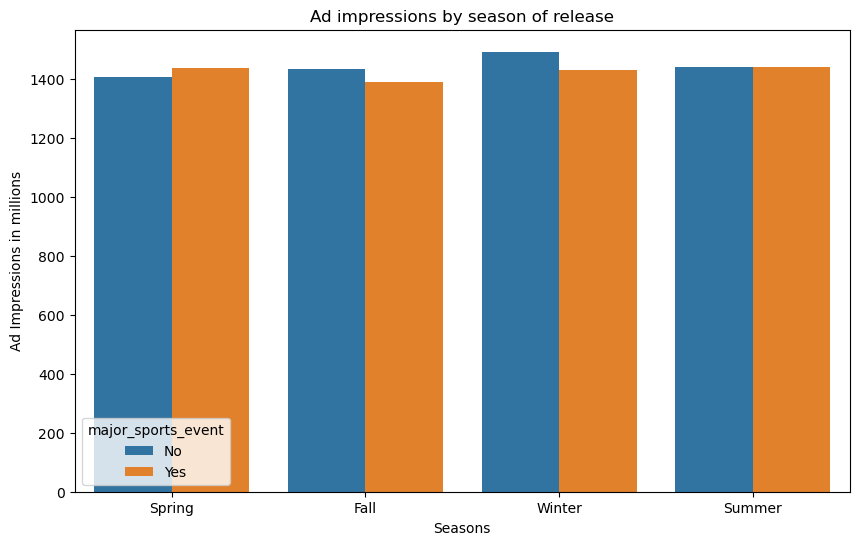

In [19]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x='season',
    y='ad_impressions',
    hue='major_sports_event',
    data=df,
    ci=None
    
    
)

plt.title('Ad impressions by season of release')
plt.xlabel('Seasons')
plt.ylabel('Ad Impressions in millions')
plt.legend(title='major_sports_event', loc='lower left')
plt.grid(False)
plt.show()

C:\Users\Subhadip\AppData\Local\Temp\ipykernel_19308\2749570178.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


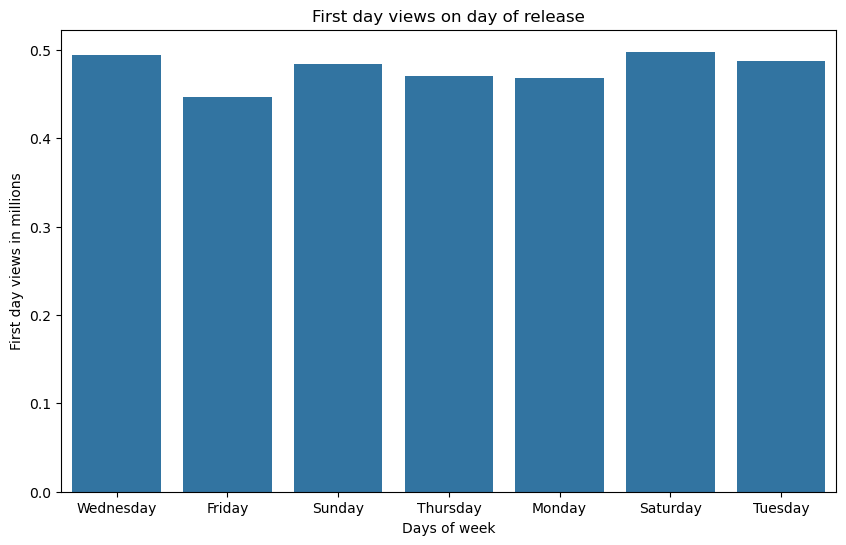

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x='dayofweek',
    y='views_content',
    data=df,
    ci=None
       
)

plt.title('First day views on day of release')
plt.xlabel('Days of week')
plt.ylabel('First day views in millions')
plt.grid(False)
plt.show()

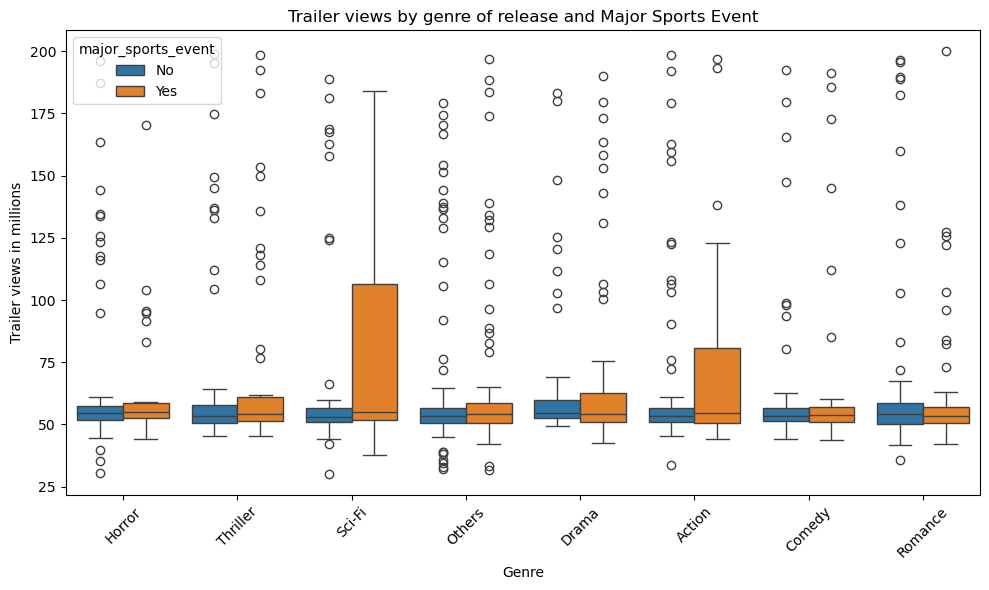

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='genre',
    y='views_trailer',
    hue='major_sports_event',
    data=df,
)

plt.title('Trailer views by genre of release and Major Sports Event')
plt.xlabel('Genre')
plt.ylabel('Trailer views in millions')
plt.legend(title='major_sports_event', loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(False)
plt.show()

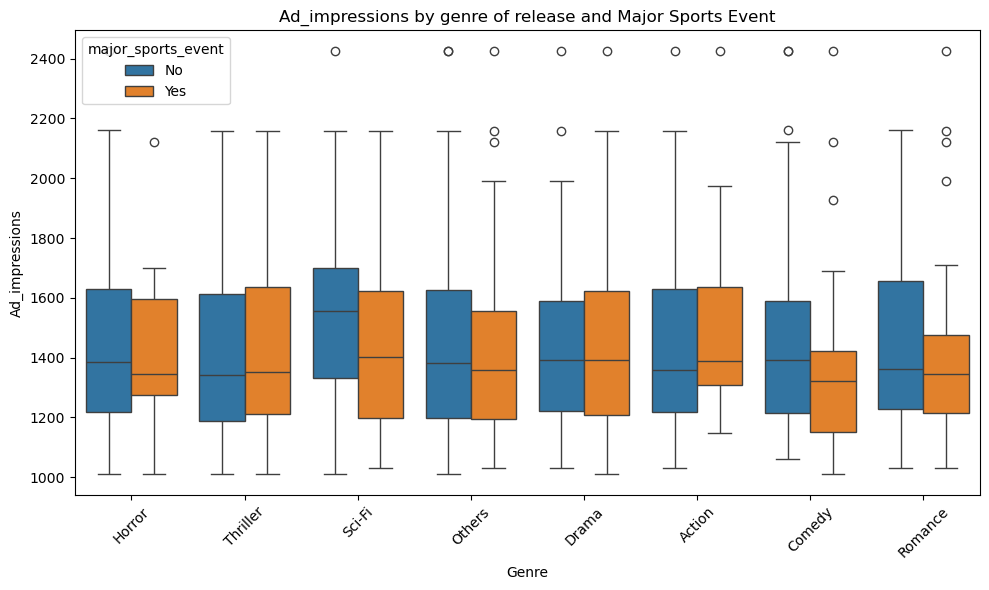

In [22]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='genre',
    y='ad_impressions',
    hue='major_sports_event',
    data=df,
)

plt.title('Ad_impressions by genre of release and Major Sports Event')
plt.xlabel('Genre')
plt.ylabel('Ad_impressions')
plt.legend(title='major_sports_event', loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(False)
plt.show()

C:\Users\Subhadip\AppData\Local\Temp\ipykernel_19308\4170476650.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


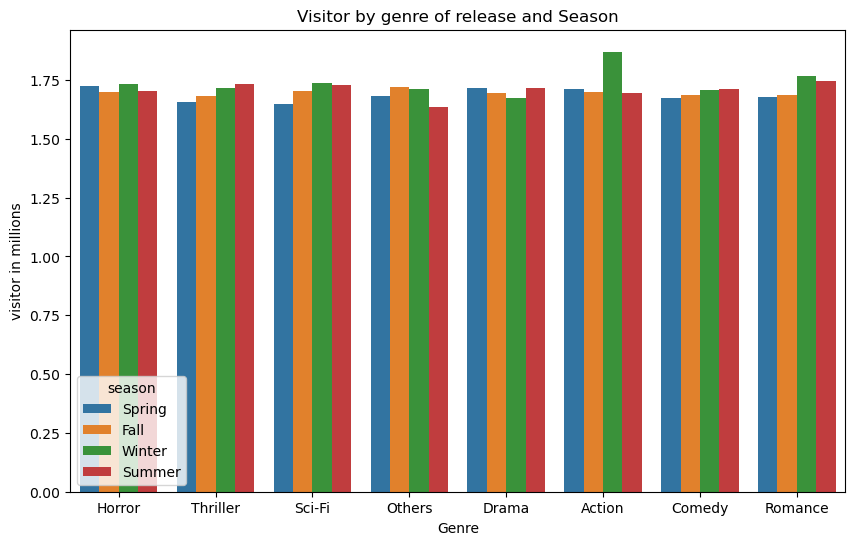

In [23]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x='genre',
    y='visitors',
    hue='season',
    data=df,
    ci=None
    
    
)

plt.title('Visitor by genre of release and Season')
plt.xlabel('Genre')
plt.ylabel('visitor in millions')
plt.legend(title='season', loc='lower left')
plt.grid(False)
plt.show()

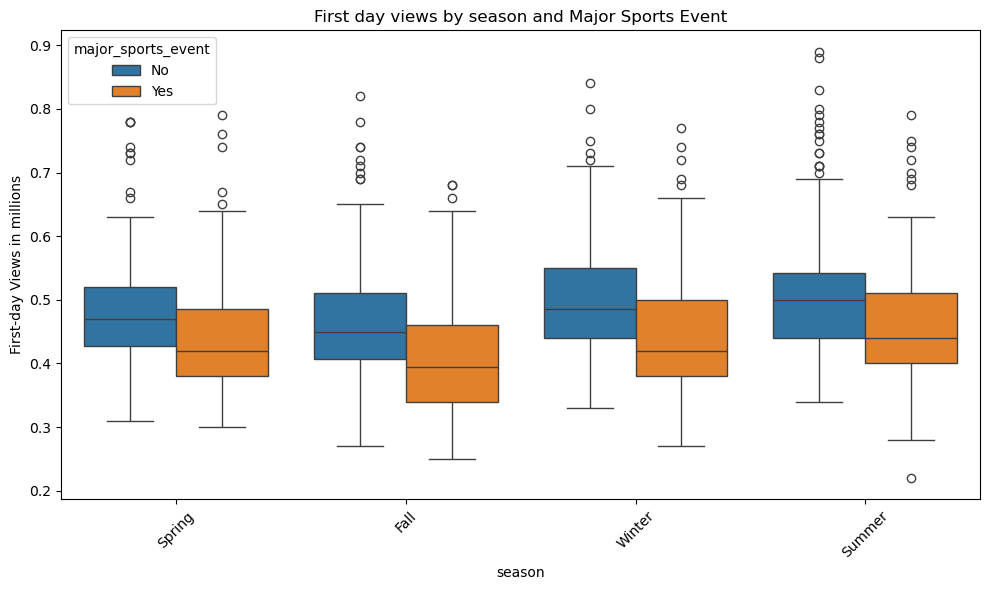

In [24]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='season',
    y='views_content',
    hue='major_sports_event',
    data=df,
)

plt.title('First day views by season and Major Sports Event')
plt.xlabel('season')
plt.ylabel('First-day Views in millions')
plt.legend(title='major_sports_event', loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(False)
plt.show()

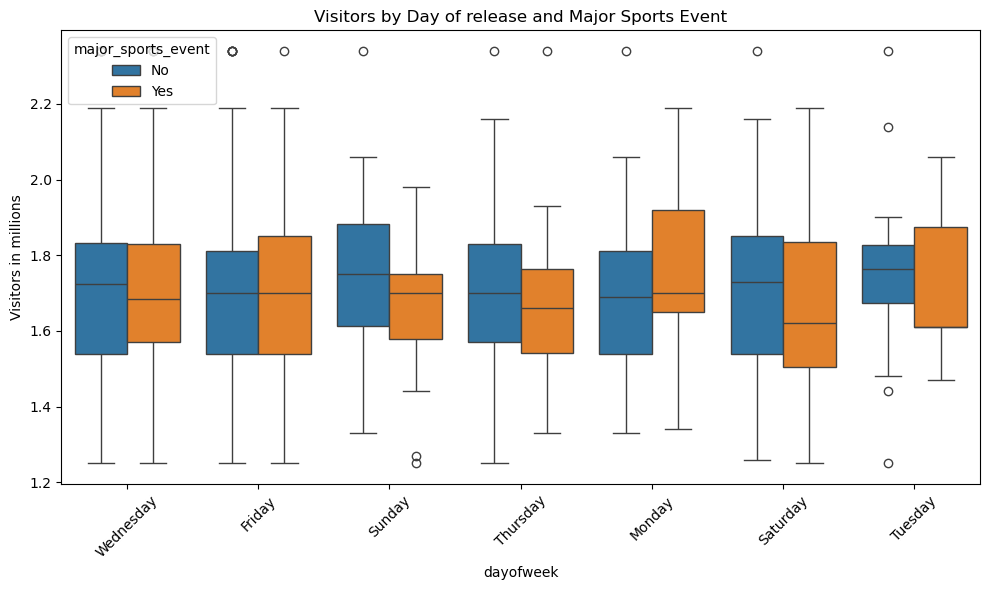

In [25]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='dayofweek',
    y='visitors',
    hue='major_sports_event',
    data=df,
)

plt.title('Visitors by Day of release and Major Sports Event')
plt.xlabel('dayofweek')
plt.ylabel('Visitors in millions')
plt.legend(title='major_sports_event', loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(False)
plt.show()

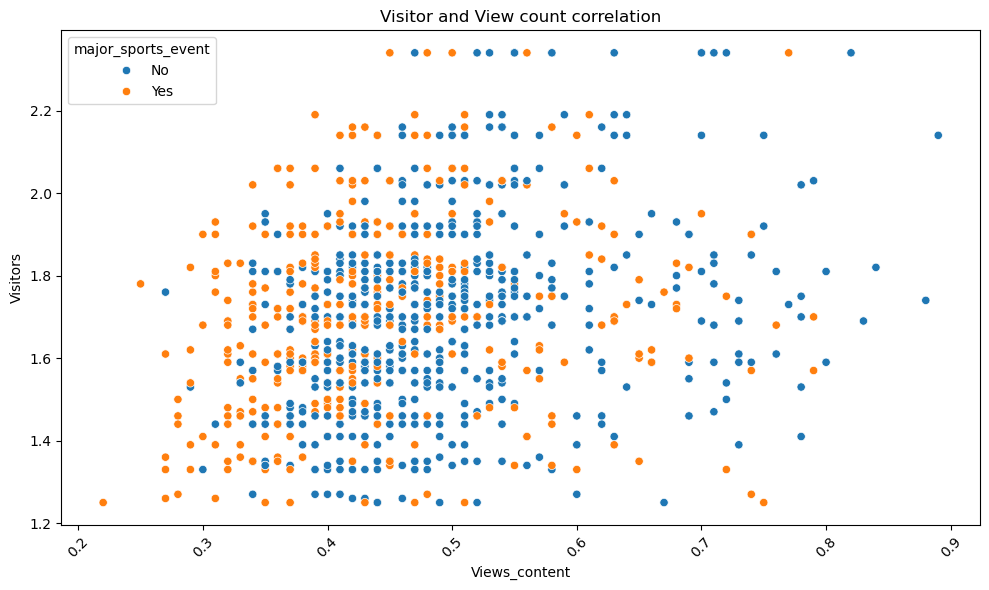

In [26]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='views_content',
    y='visitors',
    hue='major_sports_event',
    data=df,
)

plt.title('Visitor and View count correlation')
plt.xlabel('Views_content')
plt.ylabel('Visitors')
plt.legend(title='major_sports_event', loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(False)
plt.show()

<Figure size 1000x600 with 0 Axes>

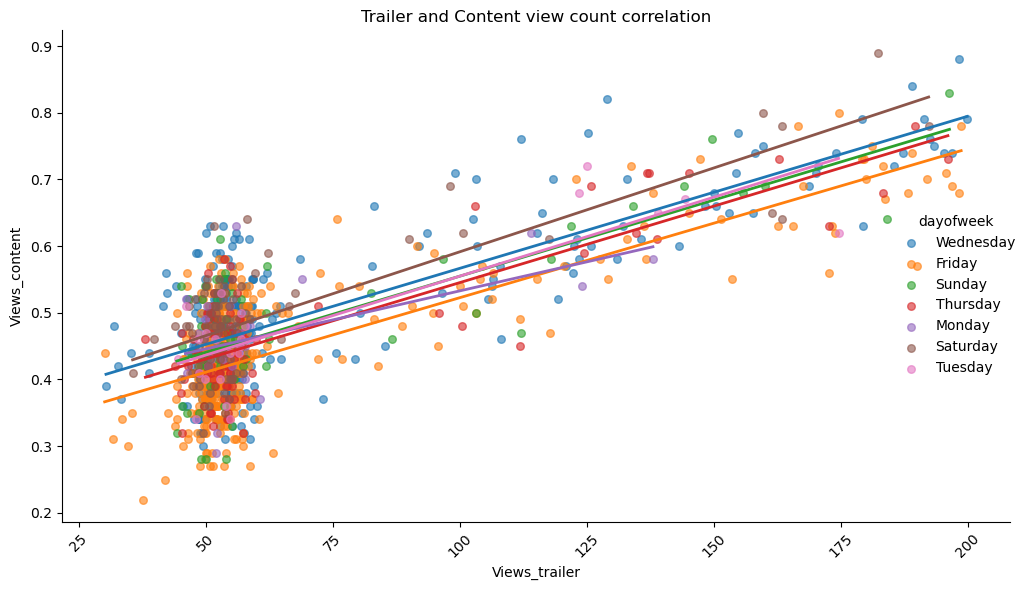

In [27]:
plt.figure(figsize=(10, 6))
sns.lmplot(
    x='views_trailer',
    y='views_content',
    hue='dayofweek',
    data=df,
    height=6,
    aspect=1.5,
    ci=None,
    scatter_kws={'alpha': 0.6, 's': 30},  # Customize scatter points
    line_kws={'linewidth': 2}  # Customize regression line
)

plt.title('Trailer and Content view count correlation')
plt.xlabel('Views_trailer')
plt.ylabel('Views_content')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(False)
plt.show()

In [28]:
print(df[["major_sports_event", "genre", "dayofweek", "season"]].dtypes)

major_sports_event    object
genre                 object
dayofweek             object
season                object
dtype: object


In [57]:
# Data preparation for modeling
# Crating Dummy Data
# drop_first=True will drop one of the three origin columns
df = pd.get_dummies(df, columns=["major_sports_event", "genre", "dayofweek", "season"], drop_first=True, dtype="uint8")
df.head()

,visitors,ad_impressions,views_trailer,views_content,major_sports_event_Yes,genre_Comedy,genre_Drama,genre_Horror,genre_Others,genre_Romance,...,genre_Thriller,dayofweek_Monday,dayofweek_Saturday,dayofweek_Sunday,dayofweek_Thursday,dayofweek_Tuesday,dayofweek_Wednesday,season_Spring,season_Summer,season_Winter
0,1.67,1113.81,56.70,0.51,0,0,0,1,0,0,...,0,0,0,0,0,0,1,1,0,0
1,1.46,1498.41,52.69,0.32,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
2,1.47,1079.19,48.74,0.39,1,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
3,1.85,1342.77,49.81,0.44,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1.46,1498.41,55.83,0.46,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1


In [59]:
# independent variables
X = df.drop(["views_content"], axis=1)
# dependent variable
y = df[["views_content"]]

In [61]:
# let's add the intercept to data
X = sm.add_constant(X)

In [63]:
#Spliting X and y into train and test sets in a 70:30 ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=1
)

In [65]:
print(X_train.head())

     const  visitors  ad_impressions  views_trailer  major_sports_event_Yes  \
731    1.0      1.64         1992.53          49.62                       0   
716    1.0      1.69         2158.03         132.93                       0   
640    1.0      1.47         1229.35          54.13                       0   
804    1.0      1.49         1010.87         106.62                       0   
737    1.0      2.19         1119.90          52.04                       0   

     genre_Comedy  genre_Drama  genre_Horror  genre_Others  genre_Romance  \
731             0            1             0             0              0   
716             0            0             0             0              0   
640             0            0             0             1              0   
804             0            0             1             0              0   
737             0            0             0             0              0   

     ...  genre_Thriller  dayofweek_Monday  dayofweek_Saturday

In [67]:
print(X_test.head())

     const  visitors  ad_impressions  views_trailer  major_sports_event_Yes  \
507    1.0      1.58         1323.74          57.85                       0   
818    1.0      1.54         2122.33          56.82                       0   
452    1.0      1.82         1152.29         165.58                       0   
368    1.0      2.03         1145.37          59.99                       0   
242    1.0      1.75         1060.86          58.99                       0   

     genre_Comedy  genre_Drama  genre_Horror  genre_Others  genre_Romance  \
507             1            0             0             0              0   
818             0            0             0             0              0   
452             1            0             0             0              0   
368             0            0             0             0              0   
242             0            0             0             0              0   

     ...  genre_Thriller  dayofweek_Monday  dayofweek_Saturday

In [69]:
#Fitting Linear Model
olsmod = sm.OLS(y_train, X_train)
olsres = olsmod.fit()

In [71]:
# let's print the regression summary
print(olsres.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.792
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     129.0
Date:                Sun, 10 Aug 2025   Prob (F-statistic):          1.32e-215
Time:                        12:13:57   Log-Likelihood:                 1124.6
No. Observations:                 700   AIC:                            -2207.
Df Residuals:                     679   BIC:                            -2112.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

In [73]:
# let's check the VIF of the predictors
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_series1 = pd.Series(
    [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])],
    index=X_train.columns,
)
print("VIF values: \n\n{}\n".format(vif_series1))

VIF values: 

const                     99.679317
visitors                   1.027837
ad_impressions             1.029390
views_trailer              1.023551
major_sports_event_Yes     1.065689
genre_Comedy               1.917635
genre_Drama                1.926699
genre_Horror               1.904460
genre_Others               2.573779
genre_Romance              1.753525
genre_Sci-Fi               1.863473
genre_Thriller             1.921001
dayofweek_Monday           1.063551
dayofweek_Saturday         1.155744
dayofweek_Sunday           1.150409
dayofweek_Thursday         1.169870
dayofweek_Tuesday          1.062793
dayofweek_Wednesday        1.315231
season_Spring              1.541591
season_Summer              1.568240
season_Winter              1.570338
dtype: float64



In [75]:
# let us create the dataframe with actual, fitted and residual values
df_pred = pd.DataFrame()

df_pred["Actual Values"] = y_train.values.flatten()  # actual values
df_pred["Fitted Values"] = olsres.fittedvalues.values  # predicted values
df_pred["Residuals"] = olsres.resid.values  # residuals

df_pred.head()

,Actual Values,Fitted Values,Residuals
0,0.40,0.452102,-0.052102
1,0.70,0.679675,0.020325
2,0.42,0.431537,-0.011537
3,0.55,0.562329,-0.012329
4,0.59,0.552069,0.037931


In [77]:
# let's make predictions on the test set
y_pred = olsres.predict(X_test)
y_pred

507    0.472532
818    0.439463
452    0.695031
368    0.502594
242    0.480877
         ...   
459    0.433206
415    0.403381
61     0.775798
347    0.405409
349    0.542766
Length: 300, dtype: float64

In [79]:
# let's check the RMSE on the train data
rmse1 = np.sqrt(mean_squared_error(y_train, df_pred["Fitted Values"]))
rmse1

0.048530261675023716

In [81]:
# let's check the RMSE on the test data
rmse2 = np.sqrt(mean_squared_error(y_test, y_pred))
rmse2

0.050602885246312956

In [83]:
# let's check the MAE on the train data
mae1 = mean_absolute_error(y_train, df_pred["Fitted Values"])
mae1

0.03819707640826122

In [85]:
# let's check the MAE on the test data
mae2 = mean_absolute_error(y_test, y_pred)
mae2

0.040781869184769254

In [87]:
# let's check the MAPE on the train data
from sklearn.metrics import mean_absolute_percentage_error

mape1 = mean_absolute_percentage_error(df_pred["Actual Values"], df_pred["Fitted Values"]) * 100
mape1

8.556439771377548

In [89]:
# let's check the MAPE on the test data
mape2 = mean_absolute_percentage_error(y_test, y_pred) * 100
mape2

9.030464032984522

In [91]:
#Checking R-Square and Adj.R-Square of test data
from sklearn.metrics import r2_score
r2_test = r2_score(y_test, y_pred)

n = X_test.shape[0]
p = X_test.shape[1]
adj_r2_test = 1 - (1 - r2_test) * (n - 1) / (n - p - 1)

print(f"Test R-squared: {r2_test:.4f}")
print(f"Test Adjusted R-squared: {adj_r2_test:.4f}")

Test R-squared: 0.7664
Test Adjusted R-squared: 0.7488


In [93]:
X_train2 = X_train.drop(["genre_Others"], axis=1)
olsmod_1 = sm.OLS(y_train, X_train2)
olsres_1 = olsmod_1.fit()
print(
    "R-squared:",
    np.round(olsres_1.rsquared, 3),
    "\nAdjusted R-squared:",
    np.round(olsres_1.rsquared_adj, 3),
)

R-squared: 0.791 
Adjusted R-squared: 0.786


In [95]:
# Droping genre_Others since Adjusted R-squared increased by 0.001
X_train = X_train.drop(["genre_Others"], axis=1)

In [97]:
olsmod_2 = sm.OLS(y_train, X_train)
olsres_2 = olsmod_2.fit()
print(olsres_2.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.791
Model:                            OLS   Adj. R-squared:                  0.786
Method:                 Least Squares   F-statistic:                     135.8
Date:                Sun, 10 Aug 2025   Prob (F-statistic):          1.66e-216
Time:                        12:14:04   Log-Likelihood:                 1124.2
No. Observations:                 700   AIC:                            -2208.
Df Residuals:                     680   BIC:                            -2117.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

In [99]:
X_train = X_train.drop(["genre_Romance"], axis=1)
olsmod_3 = sm.OLS(y_train, X_train)
olsres_3 = olsmod_3.fit()
print(olsres_3.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.791
Model:                            OLS   Adj. R-squared:                  0.786
Method:                 Least Squares   F-statistic:                     143.4
Date:                Sun, 10 Aug 2025   Prob (F-statistic):          1.59e-217
Time:                        12:14:05   Log-Likelihood:                 1124.1
No. Observations:                 700   AIC:                            -2210.
Df Residuals:                     681   BIC:                            -2124.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

In [101]:
X_train = X_train.drop(["genre_Thriller"], axis=1)
olsmod_4 = sm.OLS(y_train, X_train)
olsres_4 = olsmod_4.fit()
print(olsres_4.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.791
Model:                            OLS   Adj. R-squared:                  0.786
Method:                 Least Squares   F-statistic:                     151.9
Date:                Sun, 10 Aug 2025   Prob (F-statistic):          1.78e-218
Time:                        12:14:05   Log-Likelihood:                 1123.7
No. Observations:                 700   AIC:                            -2211.
Df Residuals:                     682   BIC:                            -2130.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

In [103]:
X_train = X_train.drop(["genre_Horror"], axis=1)
olsmod_5 = sm.OLS(y_train, X_train)
olsres_5 = olsmod_5.fit()
print(olsres_5.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.791
Model:                            OLS   Adj. R-squared:                  0.786
Method:                 Least Squares   F-statistic:                     161.4
Date:                Sun, 10 Aug 2025   Prob (F-statistic):          1.96e-219
Time:                        12:14:06   Log-Likelihood:                 1123.4
No. Observations:                 700   AIC:                            -2213.
Df Residuals:                     683   BIC:                            -2135.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

In [105]:
X_train = X_train.drop(["genre_Comedy"], axis=1)
olsmod_6 = sm.OLS(y_train, X_train)
olsres_6 = olsmod_6.fit()
print(olsres_6.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.791
Model:                            OLS   Adj. R-squared:                  0.786
Method:                 Least Squares   F-statistic:                     172.3
Date:                Sun, 10 Aug 2025   Prob (F-statistic):          1.82e-220
Time:                        12:14:06   Log-Likelihood:                 1123.1
No. Observations:                 700   AIC:                            -2214.
Df Residuals:                     684   BIC:                            -2141.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

In [107]:
X_train = X_train.drop(["genre_Drama"], axis=1)
olsmod_7 = sm.OLS(y_train, X_train)
olsres_7 = olsmod_7.fit()
print(olsres_7.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.790
Model:                            OLS   Adj. R-squared:                  0.786
Method:                 Least Squares   F-statistic:                     184.5
Date:                Sun, 10 Aug 2025   Prob (F-statistic):          2.39e-221
Time:                        12:14:06   Log-Likelihood:                 1122.5
No. Observations:                 700   AIC:                            -2215.
Df Residuals:                     685   BIC:                            -2147.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

In [109]:
X_train = X_train.drop(["genre_Sci-Fi"], axis=1)
olsmod_8 = sm.OLS(y_train, X_train)
olsres_8 = olsmod_8.fit()
print(olsres_8.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.790
Model:                            OLS   Adj. R-squared:                  0.786
Method:                 Least Squares   F-statistic:                     198.5
Date:                Sun, 10 Aug 2025   Prob (F-statistic):          2.80e-222
Time:                        12:14:07   Log-Likelihood:                 1122.0
No. Observations:                 700   AIC:                            -2216.
Df Residuals:                     686   BIC:                            -2152.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

In [111]:
X_train = X_train.drop(["dayofweek_Tuesday"], axis=1)
olsmod_9 = sm.OLS(y_train, X_train)
olsres_9 = olsmod_9.fit()
print(olsres_9.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.789
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     214.1
Date:                Sun, 10 Aug 2025   Prob (F-statistic):          9.54e-223
Time:                        12:14:07   Log-Likelihood:                 1120.3
No. Observations:                 700   AIC:                            -2215.
Df Residuals:                     687   BIC:                            -2155.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

In [113]:
X_train = X_train.drop(["ad_impressions"], axis=1)
olsmod_10 = sm.OLS(y_train, X_train)
olsres_10 = olsmod_10.fit()
print(olsres_10.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.789
Model:                            OLS   Adj. R-squared:                  0.786
Method:                 Least Squares   F-statistic:                     233.8
Date:                Sun, 10 Aug 2025   Prob (F-statistic):          7.03e-224
Time:                        12:14:07   Log-Likelihood:                 1120.2
No. Observations:                 700   AIC:                            -2216.
Df Residuals:                     688   BIC:                            -2162.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

In [115]:
# let us recreate the dataframe with actual, fitted and residual values
df_pred1 = pd.DataFrame()

df_pred1["Actual Values"] = y_train.values.flatten()  # actual values
df_pred1["Fitted Values"] = olsres_10.fittedvalues.values  # predicted values
df_pred1["Residuals"] = olsres_10.resid.values  # residuals

df_pred1.head()

,Actual Values,Fitted Values,Residuals
0,0.40,0.445434,-0.045434
1,0.70,0.677403,0.022597
2,0.42,0.433999,-0.013999
3,0.55,0.562030,-0.012030
4,0.59,0.547786,0.042214


In [117]:
X_train.columns

Index(['const', 'visitors', 'views_trailer', 'major_sports_event_Yes',
       'dayofweek_Monday', 'dayofweek_Saturday', 'dayofweek_Sunday',
       'dayofweek_Thursday', 'dayofweek_Wednesday', 'season_Spring',
       'season_Summer', 'season_Winter'],
      dtype='object')

In [119]:
X_test.columns

Index(['const', 'visitors', 'ad_impressions', 'views_trailer',
       'major_sports_event_Yes', 'genre_Comedy', 'genre_Drama', 'genre_Horror',
       'genre_Others', 'genre_Romance', 'genre_Sci-Fi', 'genre_Thriller',
       'dayofweek_Monday', 'dayofweek_Saturday', 'dayofweek_Sunday',
       'dayofweek_Thursday', 'dayofweek_Tuesday', 'dayofweek_Wednesday',
       'season_Spring', 'season_Summer', 'season_Winter'],
      dtype='object')

In [121]:
# dropping columns from the test data that are not there in the training data
X_test2 = X_test.drop(
    ["ad_impressions", "dayofweek_Tuesday", "genre_Comedy", "genre_Drama", "genre_Horror", "genre_Others", "genre_Romance", "genre_Sci-Fi", "genre_Thriller" ], axis=1
)

In [123]:
# let's make predictions on the test set
y_pred1 = olsres_10.predict(X_test2)
y_pred1

507    0.470471
818    0.443969
452    0.695562
368    0.499166
242    0.481474
         ...   
459    0.431694
415    0.407446
61     0.772899
347    0.405102
349    0.550113
Length: 300, dtype: float64

In [125]:
# let's check the RMSE on the train data
rmse3 = np.sqrt(mean_squared_error(y_train, df_pred1["Fitted Values"]))
rmse3

0.048841191125567604

In [127]:
# let's check the RMSE on the test data
rmse4 = np.sqrt(mean_squared_error(y_test,y_pred1))
rmse4

0.05110882977473584

In [129]:
# let's check the MAE on the train data
mae3 = mean_absolute_error(y_train, df_pred1["Fitted Values"])
mae3

0.03838493272194791

In [131]:
# let's check the MAE on the test data
mae4 = mean_absolute_error(y_test, y_pred1)
mae4

0.041299165383103374

In [133]:
mape3 = mean_absolute_percentage_error(df_pred1["Actual Values"], df_pred1["Fitted Values"]) * 100
mape3

8.595246363691405

In [135]:
# let's check the MAPE on the test data
mape4 = mean_absolute_percentage_error(y_test, y_pred1) * 100
mape4

9.177097098945378

In [137]:
#Again checking R-Square and Adj.R-Square of adjusted test data
r3_test = r2_score(y_test, y_pred1)

n = X_test2.shape[0]
p = X_test2.shape[1]
adj_r3_test = 1 - (1 - r3_test) * (n - 1) / (n - p - 1)

print(f"Test R-squared: {r3_test:.4f}")
print(f"Test Adjusted R-squared: {adj_r3_test:.4f}")

Test R-squared: 0.7618
Test Adjusted R-squared: 0.7518


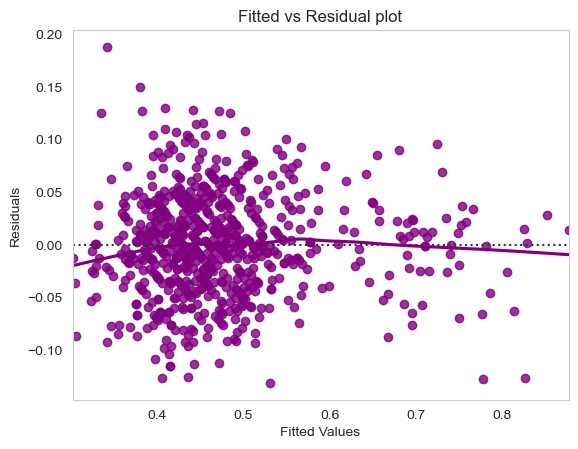

In [139]:
# let us plot the fitted values vs residuals to check Linearity of variables
sns.set_style("whitegrid")
sns.residplot(
    data=df_pred1, x="Fitted Values", y="Residuals", color="purple", lowess=True
)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Fitted vs Residual plot")
plt.grid(False)
plt.show()

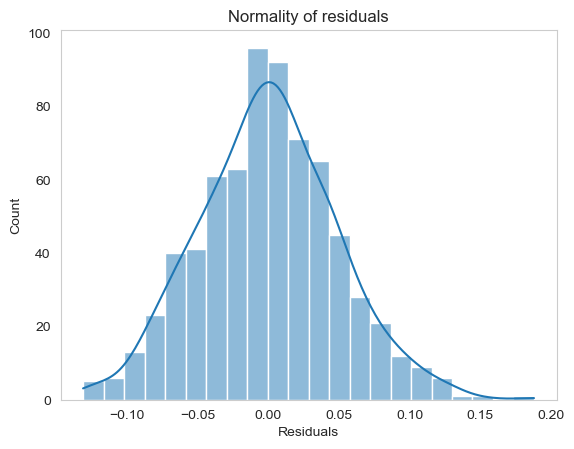

In [141]:
# TEST FOR NORMALITY
sns.histplot(df_pred1["Residuals"], kde=True)
plt.title("Normality of residuals")
plt.grid(False)
plt.show()

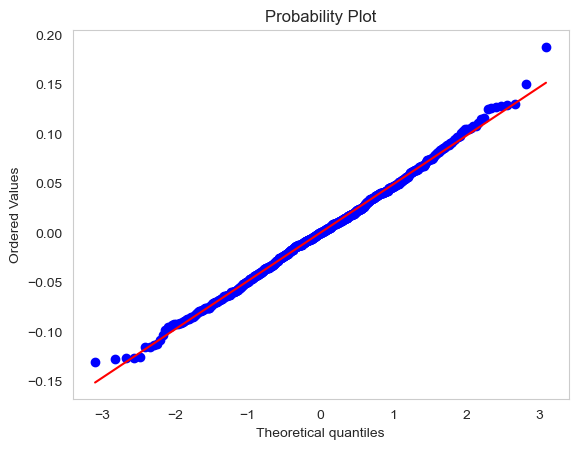

In [143]:
#QQ Plot to check normality assumption
import pylab
import scipy.stats as stats

stats.probplot(df_pred1["Residuals"], dist="norm", plot=pylab)
plt.grid(False)
plt.show()

In [145]:
# Shapiro-Wilk test to check normality assumption
stats.shapiro(df_pred1["Residuals"])

ShapiroResult(statistic=0.9973155427169234, pvalue=0.31085896470043806)

In [147]:
# TEST FOR HOMOSCEDASTICITY

import statsmodels.stats.api as sms
from statsmodels.compat import lzip

name = ["F statistic", "p-value"]
test = sms.het_goldfeldquandt(df_pred1["Residuals"], X_train)
lzip(name, test)

[('F statistic', 1.131361290420075), ('p-value', 0.12853551819087372)]

In [149]:
# let's check the model parameters
olsres_10.params

const                     0.074671
visitors                  0.129096
views_trailer             0.002331
major_sports_event_Yes   -0.060555
dayofweek_Monday          0.032066
dayofweek_Saturday        0.057029
dayofweek_Sunday          0.034386
dayofweek_Thursday        0.015449
dayofweek_Wednesday       0.046495
season_Spring             0.022605
season_Summer             0.043391
season_Winter             0.028231
dtype: float64

In [151]:
actual_values = y_test.values.flatten()

# Create DataFrame with actual and predicted values
df_results = pd.DataFrame({
    'Actual': actual_values,
    'Predicted': y_pred1
})

print(df_results.head(10))

     Actual  Predicted
507    0.43   0.470471
818    0.45   0.443969
452    0.63   0.695562
368    0.50   0.499166
242    0.50   0.481474
929    0.40   0.407007
262    0.46   0.612016
810    0.42   0.440463
318    0.51   0.502607
49     0.34   0.425296


In [153]:
# Let us write the equation of linear regression
Equation = "Content Views ="
print(Equation, end=" ")
for i in range(len(X_train.columns)):
    if i == 0:
        print(olsres_10.params[i], "+", end=" ")
    elif i != len(X_train.columns) - 1:
        print(
            olsres_10.params[i],
            "* (",
            X_train.columns[i],
            ")",
            "+",
            end="  ",
        )
    else:
        print(olsres_10.params[i], "* (", X_train.columns[i], ")")

Content Views = 0.07467052053721267 + 0.12909581825894126 * ( visitors ) +  0.002330816786164013 * ( views_trailer ) +  -0.06055507818137332 * ( major_sports_event_Yes ) +  0.03206580679023629 * ( dayofweek_Monday ) +  0.057028596601651195 * ( dayofweek_Saturday ) +  0.034386229923625 * ( dayofweek_Sunday ) +  0.01544944176997319 * ( dayofweek_Thursday ) +  0.04649480366984812 * ( dayofweek_Wednesday ) +  0.022604915818118004 * ( season_Spring ) +  0.04339100263609978 * ( season_Summer ) +  0.028230557183976823 * ( season_Winter )


C:\Users\Subhadip\AppData\Local\Temp\ipykernel_19308\2114001760.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(olsres_10.params[i], "+", end=" ")
C:\Users\Subhadip\AppData\Local\Temp\ipykernel_19308\2114001760.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  olsres_10.params[i],
C:\Users\Subhadip\AppData\Local\Temp\ipykernel_19308\2114001760.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(olsres_10.params[i]